In [1]:
import os 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns

parent_folder = "/home/abharadwaj1/thesis/data_archive/inputs/5_vitrification/nucleate_boiling"

/tmp/ipykernel_16232/675740232.py:3: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


In [2]:
high_temperature_data_files = [os.path.join(parent_folder, f) for f in os.listdir(parent_folder) if "160mm" in f and f.endswith(".csv")]
low_temperature_data_files = [os.path.join(parent_folder, f) for f in os.listdir(parent_folder) if "95mm" in f and f.endswith(".csv")]

# Read the data files and combine them into a single DataFrame
combined_df = pd.DataFrame()
for i, filename in enumerate(high_temperature_data_files):
    df = pd.read_csv(filename)
    df['time_us_shifted'] = df["Time (us)"] - df["Time (us)"].min()  # Shift time to start from zero
    df['time_ms'] = df['time_us_shifted'] / 1000  # Convert time from microseconds to milliseconds
    df['filename'] = os.path.basename(filename)  # Add a column for the filename
    df['trial'] = i + 1  # Add a column for the trial number
    df['condition'] = 'high_temperature'  # Add a column for the condition
    combined_df = pd.concat([combined_df, df], ignore_index=True)
for i, filename in enumerate(low_temperature_data_files):
    df = pd.read_csv(filename)
    df['filename'] = os.path.basename(filename)  # Add a column for the filename
    df['trial'] = i + 1  # Add a column for the trial number
    df['condition'] = 'low_temperature'  # Add a column for the condition
    combined_df = pd.concat([combined_df, df], ignore_index=True)

    
#combined_df['time_ms'] = combined_df["Time (us)"] / 1000  # Convert time from microseconds to milliseconds
combined_df["temperature_K"] = combined_df["Temperature (C)"] + 273.15  # Convert temperature from Celsius to Kelvin


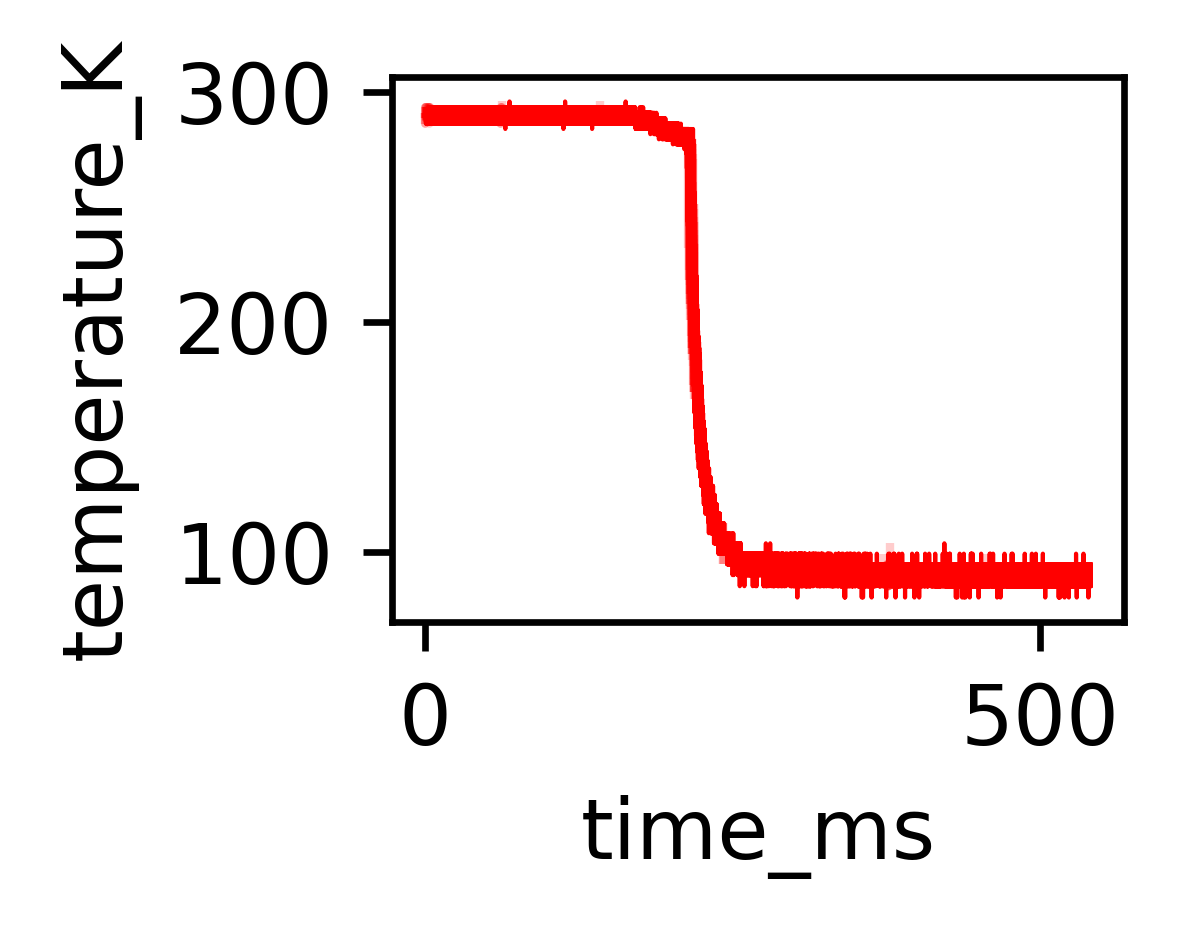

In [3]:
figsize_mm = (40, 30)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
fig, ax = plt.subplots(figsize=figsize_in, dpi=600)
#sns.set(style="white")
#sns.set_context("paper", font_scale=1.0)
sns.lineplot(data=combined_df[combined_df['condition'] == 'high_temperature'],\
            x="time_ms", y="temperature_K", \
            ax=ax, linewidth=0.5, errorbar=('ci', 95), markers=None, color="red")
#ax.set_xlim(0, 5000)
save_path = os.path.join(parent_folder, "high_temperature_plot.pdf")
ax.set_yticks([100, 200, 300])
plt.savefig(save_path, bbox_inches='tight')


In [4]:
df_low = combined_df[combined_df['condition'] == 'low_temperature']
filenames = df_low['filename'].unique()
for filename in filenames:
    df = df_low[df_low['filename'] == filename]
    df['time_ms_1'] = df["Time (us)"] - df["Time (us)"].min()  # Shift time to start from zero
    df['time_ms'] = df['time_ms_1'] / 1000  # Convert time from microseconds to milliseconds
    df_low[df_low['filename'] == filename] = df  # Update the DataFrame with the shifted time
    

/tmp/ipykernel_16232/2772690357.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_ms_1'] = df["Time (us)"] - df["Time (us)"].min()  # Shift time to start from zero
/tmp/ipykernel_16232/2772690357.py:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['time_ms'] = df['time_ms_1'] / 1000  # Convert time from microseconds to milliseconds
/tmp/ipykernel_16232/2772690357.py:7: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_ind

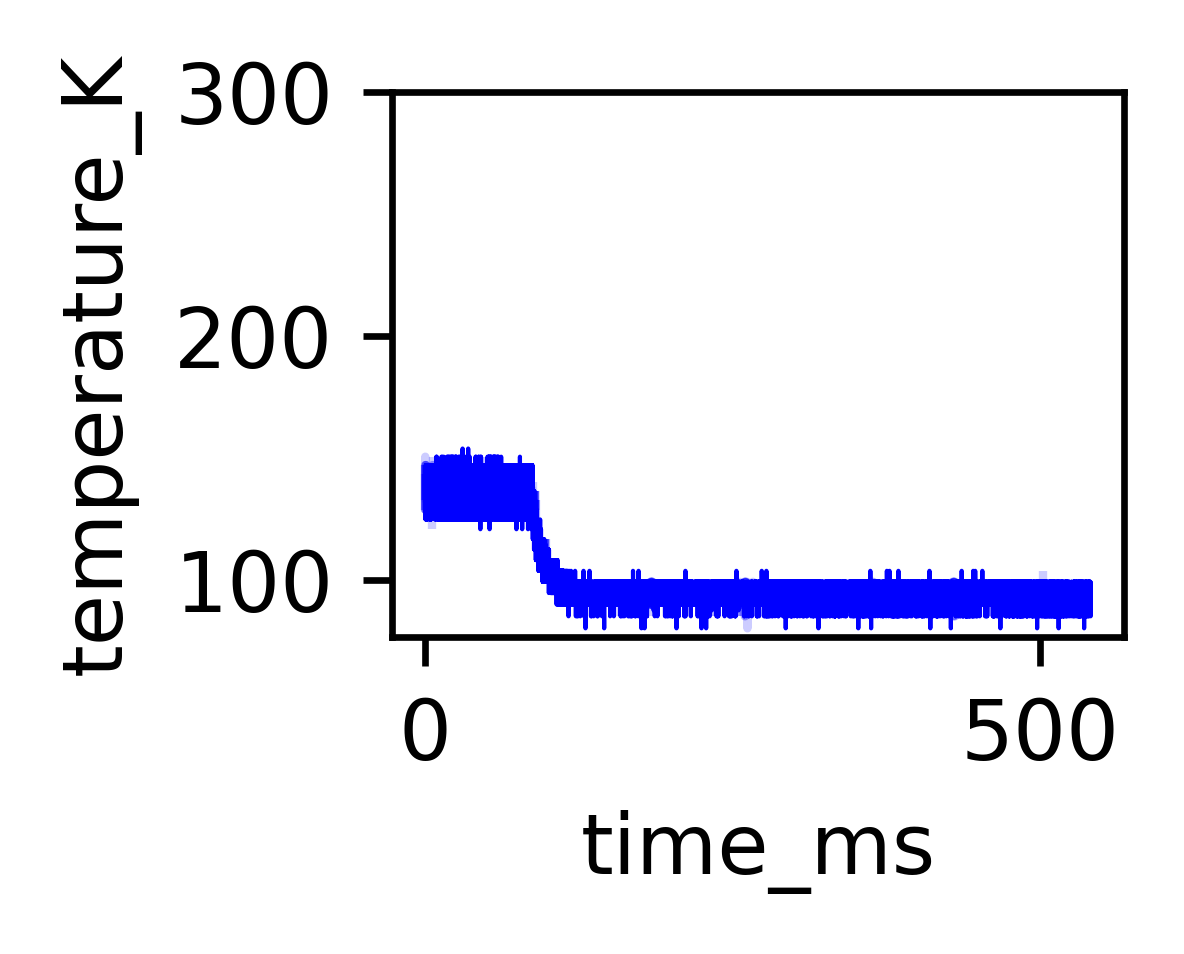

In [5]:
figsize_mm = (40, 30)
figsize_in = (figsize_mm[0] / 25.4, figsize_mm[1] / 25.4)  # Convert mm to inches
fig, ax = plt.subplots(figsize=figsize_in, dpi=600)
#sns.set(style="white")
#sns.set_context("paper", font_scale=1.0)
sns.lineplot(data=df_low,\
            x="time_ms", y="temperature_K", \
            ax=ax, linewidth=0.5, errorbar=('ci', 95), markers=None, color="blue")
#ax.set_xlim(0, 5000)
ax.set_yticks([100, 200, 300])
save_path = os.path.join(parent_folder, "low_temperature_plot.pdf")
plt.savefig(save_path, bbox_inches='tight')
